#🚦 Road Accident Severity Prediction
# Dataset: Accidents Classified According to Road Environment (MoRTH, India 2017–2023)  
# Goal: Predict Severity — Low / Medium / High / Critical  
# Top 5 Models: Stacking · Gradient Boosting · Voting · Random Forest · Bagging

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, learning_curve
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                              roc_curve, auc)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (RandomForestClassifier, AdaBoostClassifier,
                               GradientBoostingClassifier, VotingClassifier,
                               StackingClassifier, BaggingClassifier)
from imblearn.over_sampling import SMOTE

sns.set_style('whitegrid')
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
print("Libraries loaded")


Matplotlib is building the font cache; this may take a moment.


Libraries loaded


In [3]:
df = pd.read_csv("Road_Accident.csv")
df.columns = ['Country','State','Year_Raw','Road_Environment',
              'Rank_Killed','Rank_Accidents','Grievously_Injured',
              'Persons_Killed','Minor_Injured','Total_Accidents','Total_Injured']

df['Year'] = df['Year_Raw'].str.extract(r'(\d{4})').astype(int)
num_cols = ['Grievously_Injured','Persons_Killed','Minor_Injured','Total_Accidents','Total_Injured']
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
df.dropna(subset=['Total_Accidents','Persons_Killed'], inplace=True)
df[num_cols] = df[num_cols].fillna(0)

print(f"Dataset shape: {df.shape}")
df.head()


Dataset shape: (1262, 12)


,Country,State,Year_Raw,Road_Environment,Rank_Killed,Rank_Accidents,Grievously_Injured,Persons_Killed,Minor_Injured,Total_Accidents,Total_Injured,Year
0,India,Andaman and Nicobar Islands,"Calendar Year (Jan - Dec), 2023",Institutional Area,NaN,NaN,14.0,5.0,19.0,30.0,33.0,2023
1,India,Andaman and Nicobar Islands,"Calendar Year (Jan - Dec), 2023",Market/ Commercial Area,NaN,NaN,21.0,4.0,24.0,46.0,45.0,2023
2,India,Andaman and Nicobar Islands,"Calendar Year (Jan - Dec), 2023",Open Area,NaN,NaN,7.0,3.0,16.0,16.0,23.0,2023
3,India,Andaman and Nicobar Islands,"Calendar Year (Jan - Dec), 2023",Others,NaN,NaN,0.0,0.0,0.0,0.0,0.0,2023
4,India,Andaman and Nicobar Islands,"Calendar Year (Jan - Dec), 2023",Residential Area,NaN,NaN,18.0,12.0,35.0,51.0,53.0,2023


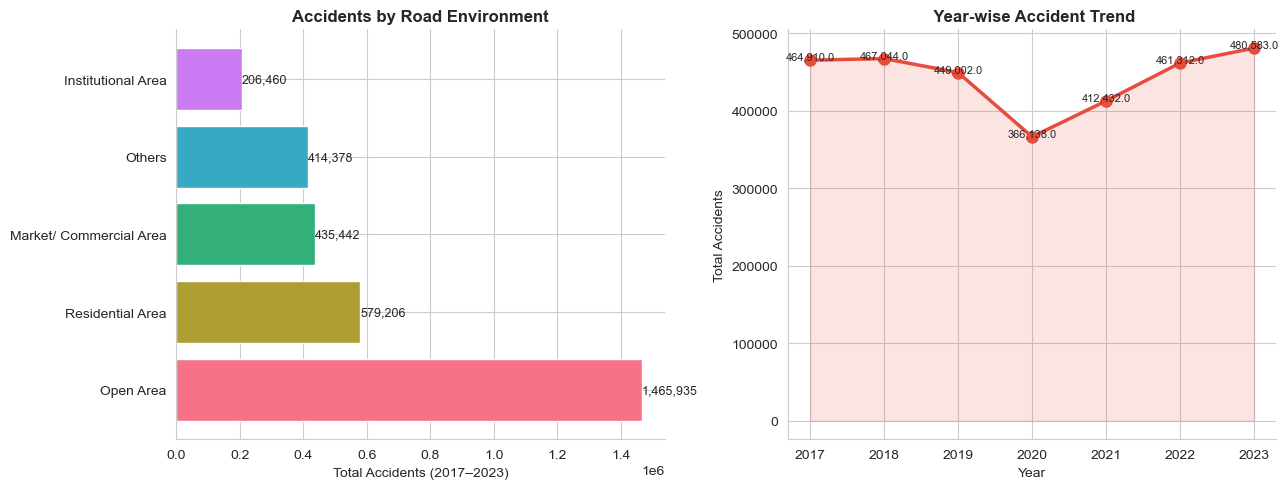

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Accidents by Road Environment
env_stats = df.groupby('Road_Environment')['Total_Accidents'].sum().sort_values(ascending=False)
colors = sns.color_palette('husl', len(env_stats))
axes[0].barh(env_stats.index, env_stats.values, color=colors)
axes[0].set_xlabel('Total Accidents (2017–2023)')
axes[0].set_title('Accidents by Road Environment', fontweight='bold')
for i, v in enumerate(env_stats.values):
    axes[0].text(v + 500, i, f'{v:,.0f}', va='center', fontsize=9)

# Year-wise trend
year_trend = df.groupby('Year')['Total_Accidents'].sum()
axes[1].plot(year_trend.index, year_trend.values, marker='o', linewidth=2.5,
             color='#e74c3c', markersize=8)
axes[1].fill_between(year_trend.index, year_trend.values, alpha=0.15, color='#e74c3c')
axes[1].set_xlabel('Year'); axes[1].set_ylabel('Total Accidents')
axes[1].set_title(' Year-wise Accident Trend', fontweight='bold')
axes[1].set_xticks(year_trend.index)
for x, y in zip(year_trend.index, year_trend.values):
    axes[1].text(x, y + 500, f'{y:,}', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()


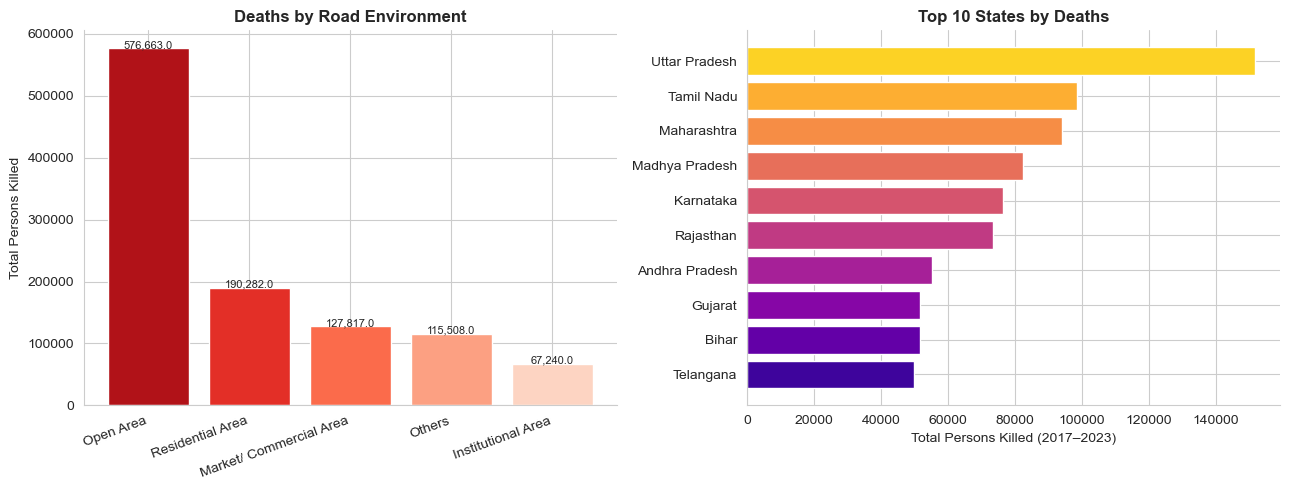

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Deaths by environment
death_env = df.groupby('Road_Environment')['Persons_Killed'].sum().sort_values(ascending=False)
axes[0].bar(death_env.index, death_env.values,
            color=sns.color_palette('Reds_r', len(death_env)))
axes[0].set_xticklabels(death_env.index, rotation=20, ha='right')
axes[0].set_ylabel('Total Persons Killed')
axes[0].set_title('Deaths by Road Environment', fontweight='bold')
for i, v in enumerate(death_env.values):
    axes[0].text(i, v + 200, f'{v:,}', ha='center', fontsize=8)

# Top 10 deadliest states
top_states = df.groupby('State')['Persons_Killed'].sum().nlargest(10)
axes[1].barh(top_states.index[::-1], top_states.values[::-1],
             color=sns.color_palette('plasma', 10))
axes[1].set_xlabel('Total Persons Killed (2017–2023)')
axes[1].set_title('Top 10 States by Deaths', fontweight='bold')

plt.tight_layout()
plt.savefig('eda_deaths.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
df_ml = df.copy()

df_ml['Fatality_Rate'] = df_ml['Persons_Killed']     / (df_ml['Total_Accidents'] + 1)
df_ml['Injury_Rate']   = df_ml['Total_Injured']      / (df_ml['Total_Accidents'] + 1)
df_ml['Grievous_Rate'] = df_ml['Grievously_Injured'] / (df_ml['Total_Accidents'] + 1)
df_ml['Year_Norm']     = (df_ml['Year'] - 2017) / 6

le_env, le_state = LabelEncoder(), LabelEncoder()
df_ml['Env_Code']   = le_env.fit_transform(df_ml['Road_Environment'])
df_ml['State_Code'] = le_state.fit_transform(df_ml['State'])

q1, q2, q3 = df_ml['Persons_Killed'].quantile([0.33, 0.66, 0.90]).values
def assign_severity(row):
    k = row['Persons_Killed']
    if k <= q1:   return 0
    elif k <= q2: return 1
    elif k <= q3: return 2
    else:         return 3

df_ml['Severity'] = df_ml.apply(assign_severity, axis=1)
severity_names = {0:'Low', 1:'Medium', 2:'High', 3:'Critical'}
print("Feature engineering complete")

Feature engineering complete


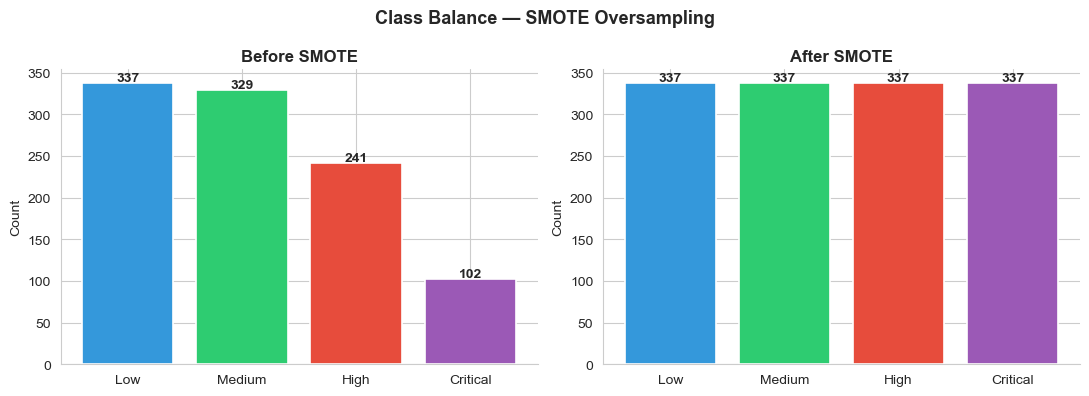

Train (after SMOTE): (1348, 10)  |  Test: (253, 10)


In [7]:
FEATURES = ['Env_Code','State_Code','Year','Year_Norm',
            'Total_Accidents','Grievously_Injured','Minor_Injured',
            'Fatality_Rate','Injury_Rate','Grievous_Rate']

X = df_ml[FEATURES].values
y = df_ml['Severity'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_train)
X_te_s = scaler.transform(X_test)

smote = SMOTE(random_state=42, k_neighbors=3)
X_tr_sm, y_tr_sm = smote.fit_resample(X_tr_s, y_train)

# ── Visual: Before vs After SMOTE ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
palette = ['#3498db','#2ecc71','#e74c3c','#9b59b6']

for ax, y_data, title in zip(axes, [y_train, y_tr_sm], ['Before SMOTE', 'After SMOTE']):
    vals, cnts = np.unique(y_data, return_counts=True)
    bars = ax.bar([severity_names[v] for v in vals], cnts,
                  color=[palette[v] for v in vals], edgecolor='white', linewidth=1.2)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Count')
    for bar, cnt in zip(bars, cnts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                str(cnt), ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Class Balance — SMOTE Oversampling', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('smote_balance.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Train (after SMOTE): {X_tr_sm.shape}  |  Test: {X_te_s.shape}")


In [8]:
classifiers = {
    'Random Forest':     RandomForestClassifier(n_estimators=200, max_depth=12,
                                                random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=150, max_depth=4,
                                                    learning_rate=0.1, random_state=42),
    'Bagging':           BaggingClassifier(n_estimators=50, random_state=42, n_jobs=-1),
    'Voting (Hard)':     VotingClassifier(estimators=[
                             ('rf',  RandomForestClassifier(n_estimators=100, random_state=42)),
                             ('gb',  GradientBoostingClassifier(n_estimators=100, random_state=42)),
                             ('ada', AdaBoostClassifier(n_estimators=80, random_state=42)),
                         ], voting='hard'),
    'Stacking':          StackingClassifier(estimators=[
                             ('rf',  RandomForestClassifier(n_estimators=100, random_state=42)),
                             ('gb',  GradientBoostingClassifier(n_estimators=100, random_state=42)),
                             ('ada', AdaBoostClassifier(n_estimators=80, random_state=42)),
                         ], final_estimator=LogisticRegression(max_iter=500), cv=3),
}
print("5 classifiers ready")

5 classifiers ready


In [ ]:
results = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f"{'Model':<20} {'Test Acc':>10} {'CV Mean':>10} {'CV Std':>8}")
print("-" * 50)

for name, clf in classifiers.items():
    clf.fit(X_tr_sm, y_tr_sm)
    y_pred    = clf.predict(X_te_s)
    acc       = accuracy_score(y_test, y_pred)
    cv_scores = cross_val_score(clf, X_tr_sm, y_tr_sm, cv=cv,
                                scoring='accuracy', n_jobs=-1)
    results[name] = {'accuracy': acc, 'cv_mean': cv_scores.mean(),
                     'cv_std': cv_scores.std(), 'y_pred': y_pred}
    print(f"{name:<20} {acc:>10.4f} {cv_scores.mean():>10.4f} ±{cv_scores.std():>6.4f}")

Model                  Test Acc    CV Mean   CV Std
--------------------------------------------------
Random Forest            0.9565     0.9540 ±0.0164
Gradient Boosting        0.9684     0.9577 ±0.0204
Bagging                  0.9565     0.9562 ±0.0127
Voting (Hard)            0.9723     0.9510 ±0.0172


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
top2 = ['Gradient Boosting', 'Stacking']
colors_lc = [('#e74c3c','#fadbd8'), ('#8e44ad','#e8daef')]

for ax, model_name, (c1, c2) in zip(axes, top2, colors_lc):
    clf = classifiers[model_name]
    train_sizes, train_scores, val_scores = learning_curve(
        clf, X_tr_sm, y_tr_sm, cv=3,
        train_sizes=np.linspace(0.2, 1.0, 6),
        scoring='accuracy', n_jobs=-1)

    tr_mean = train_scores.mean(axis=1) * 100
    tr_std  = train_scores.std(axis=1)  * 100
    va_mean = val_scores.mean(axis=1)   * 100
    va_std  = val_scores.std(axis=1)    * 100

    ax.plot(train_sizes, tr_mean, 'o-', color=c1, label='Train Accuracy', lw=2)
    ax.fill_between(train_sizes, tr_mean - tr_std, tr_mean + tr_std, alpha=0.2, color=c1)
    ax.plot(train_sizes, va_mean, 's--', color='#2c3e50', label='Validation Accuracy', lw=2)
    ax.fill_between(train_sizes, va_mean - va_std, va_mean + va_std, alpha=0.15, color=c2)

    ax.set_title(f'Learning Curve — {model_name}', fontweight='bold')
    ax.set_xlabel('Training Samples'); ax.set_ylabel('Accuracy (%)')
    ax.legend(); ax.set_ylim(75, 105)

plt.suptitle('Learning Curves (Bias-Variance Tradeoff)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
from sklearn.preprocessing import label_binarize

# Models that support predict_proba
proba_models = {n: c for n, c in classifiers.items()
                if n not in ['Voting (Hard)']}  # Hard voting has no proba

y_bin = label_binarize(y_test, classes=[0,1,2,3])
fig, axes = plt.subplots(1, len(proba_models), figsize=(15, 4))
palette_roc = ['#e74c3c','#3498db','#2ecc71','#9b59b6']

for ax, (name, clf) in zip(axes, proba_models.items()):
    y_score = clf.predict_proba(X_te_s)
    for cls_id, cls_name in severity_names.items():
        fpr, tpr, _ = roc_curve(y_bin[:, cls_id], y_score[:, cls_id])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=palette_roc[cls_id], lw=1.8,
                label=f'{cls_name} (AUC={roc_auc:.2f})')
    ax.plot([0,1],[0,1],'k--', lw=1)
    ax.set_title(name, fontweight='bold', fontsize=9)
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.legend(fontsize=7); ax.set_xlim([0,1]); ax.set_ylim([0,1.02])

plt.suptitle('ROC Curves — One-vs-Rest (per class)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
lb = pd.DataFrame({
    'Model':        list(results.keys()),
    'Accuracy (%)': [round(v['accuracy']*100, 2) for v in results.values()]
}).sort_values('Accuracy (%)', ascending=False).reset_index(drop=True)
lb.index += 1

print(" FINAL LEADERBOARD")
print(lb.to_string())

medal = ['#FFD700','#C0C0C0','#CD7F32','#85C1E9','#A9DFBF']
plt.figure(figsize=(9, 4))
bars = plt.bar(lb['Model'], lb['Accuracy (%)'],
               color=medal, edgecolor='white', linewidth=1.5, width=0.5)
plt.ylim(92, 100); plt.xticks(rotation=12, ha='right')
plt.ylabel('Accuracy (%)'); plt.title('Final Leaderboard', fontweight='bold')
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f"{bar.get_height():.2f}%", ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('leaderboard.png', dpi=150, bbox_inches='tight')
plt.show()